#### Importaciones

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from joblib import dump, load

#### 1. Preparar datos

In [2]:
def load_data(folder, filename):
    route = os.path.join(folder, filename)
    data = pd.read_csv(route)
    return data


In [3]:
# Generales:
folder = "./datasets"
file_name_training = "gold_recovery_train.csv"
file_name_test = "gold_recovery_test.csv"

##### 1.1. Carga de datos

In [4]:
training_data = load_data(folder, file_name_training)
test_data = load_data(folder, file_name_test)

#### Explorar datos (EDA)

##### Exploracion inicial

In [5]:
training_data.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [6]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  str    
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64
 9   final.

In [7]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   str    
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_cleaner.state.f

#### Conclusiones de 1.1

- Se observan muchas variables innecesarias. Se recomienda filtrar el dataframe para que solo contenga lo relacionado al oro.
- Los datos presentan valores ausentes o nulos. 
- Se recomienda revisar si hay datos duplicados.
- Lo mejor es eliinar esas filas con valores ausentes. Hay suficientes datos para entrenar el modelo.
- Para el modelo lineal se recomienda usar un scaler para que los datos estén en el mismo orden de magnitud.

#### 1.2. Calculo de recovery

Comprueba que el cálculo de la recuperación sea correcto. Calcula la recuperación de la característica rougher.output.recovery mediante el conjunto de entrenamiento. Encuentra el EAM entre tus cálculos y los valores de la característica. Facilita los resultados.


In [8]:
# Crear un nuevo dataframe que contenga solo las columnas relacionadas con el Oro y los target de recuperacion (rougher.output.recovery y final.output.recovery)
columnas_de_interes = []
for column in training_data.columns:
    if "_au" in column:
        columnas_de_interes.append(column) 
    elif column == "rougher.output.recovery":
        columnas_de_interes.append(column)
    elif column == "final.output.recovery":
        columnas_de_interes.append(column)

df_rougher = training_data[columnas_de_interes]
df_rougher.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   final.output.concentrate_au                         16789 non-null  float64
 1   final.output.recovery                               15339 non-null  float64
 2   final.output.tail_au                                16794 non-null  float64
 3   primary_cleaner.output.concentrate_au               16778 non-null  float64
 4   primary_cleaner.output.tail_au                      16777 non-null  float64
 5   rougher.calculation.sulfate_to_au_concentrate       16833 non-null  float64
 6   rougher.calculation.floatbank10_sulfate_to_au_feed  16833 non-null  float64
 7   rougher.calculation.floatbank11_sulfate_to_au_feed  16833 non-null  float64
 8   rougher.input.feed_au                               16777 non-null  float64
 9   roughe

Conclusión del filtrado de datos:
- Las filas duplicadas eran las mismas que las filas con datos nulos.

Calcular los datos de la recuperación teórica de oro de acuerdo a la fórmula. Este cálculo se debe incluir como fila en los datos

Recuperacion = (C*(F-T))/(F*(C-T))

Este cálculo teórico permite obtener las 2 recuperaciones del proceso:

1. La recuperación del concentrado rougher (corresponde al 3 en la figura)
En este caso las variables significan lo siguiente:

- C -> rougher.ouput.concentrate_au
- F -> rougher.input.feed_au
- T -> rougher.output.tail_au

2. La recuperación del concentrado final (corresponde al 8 en la figura)

- C -> final.output.concentrate_au
- F -> rougher.input.feed_au
- T -> final.output.tail_au

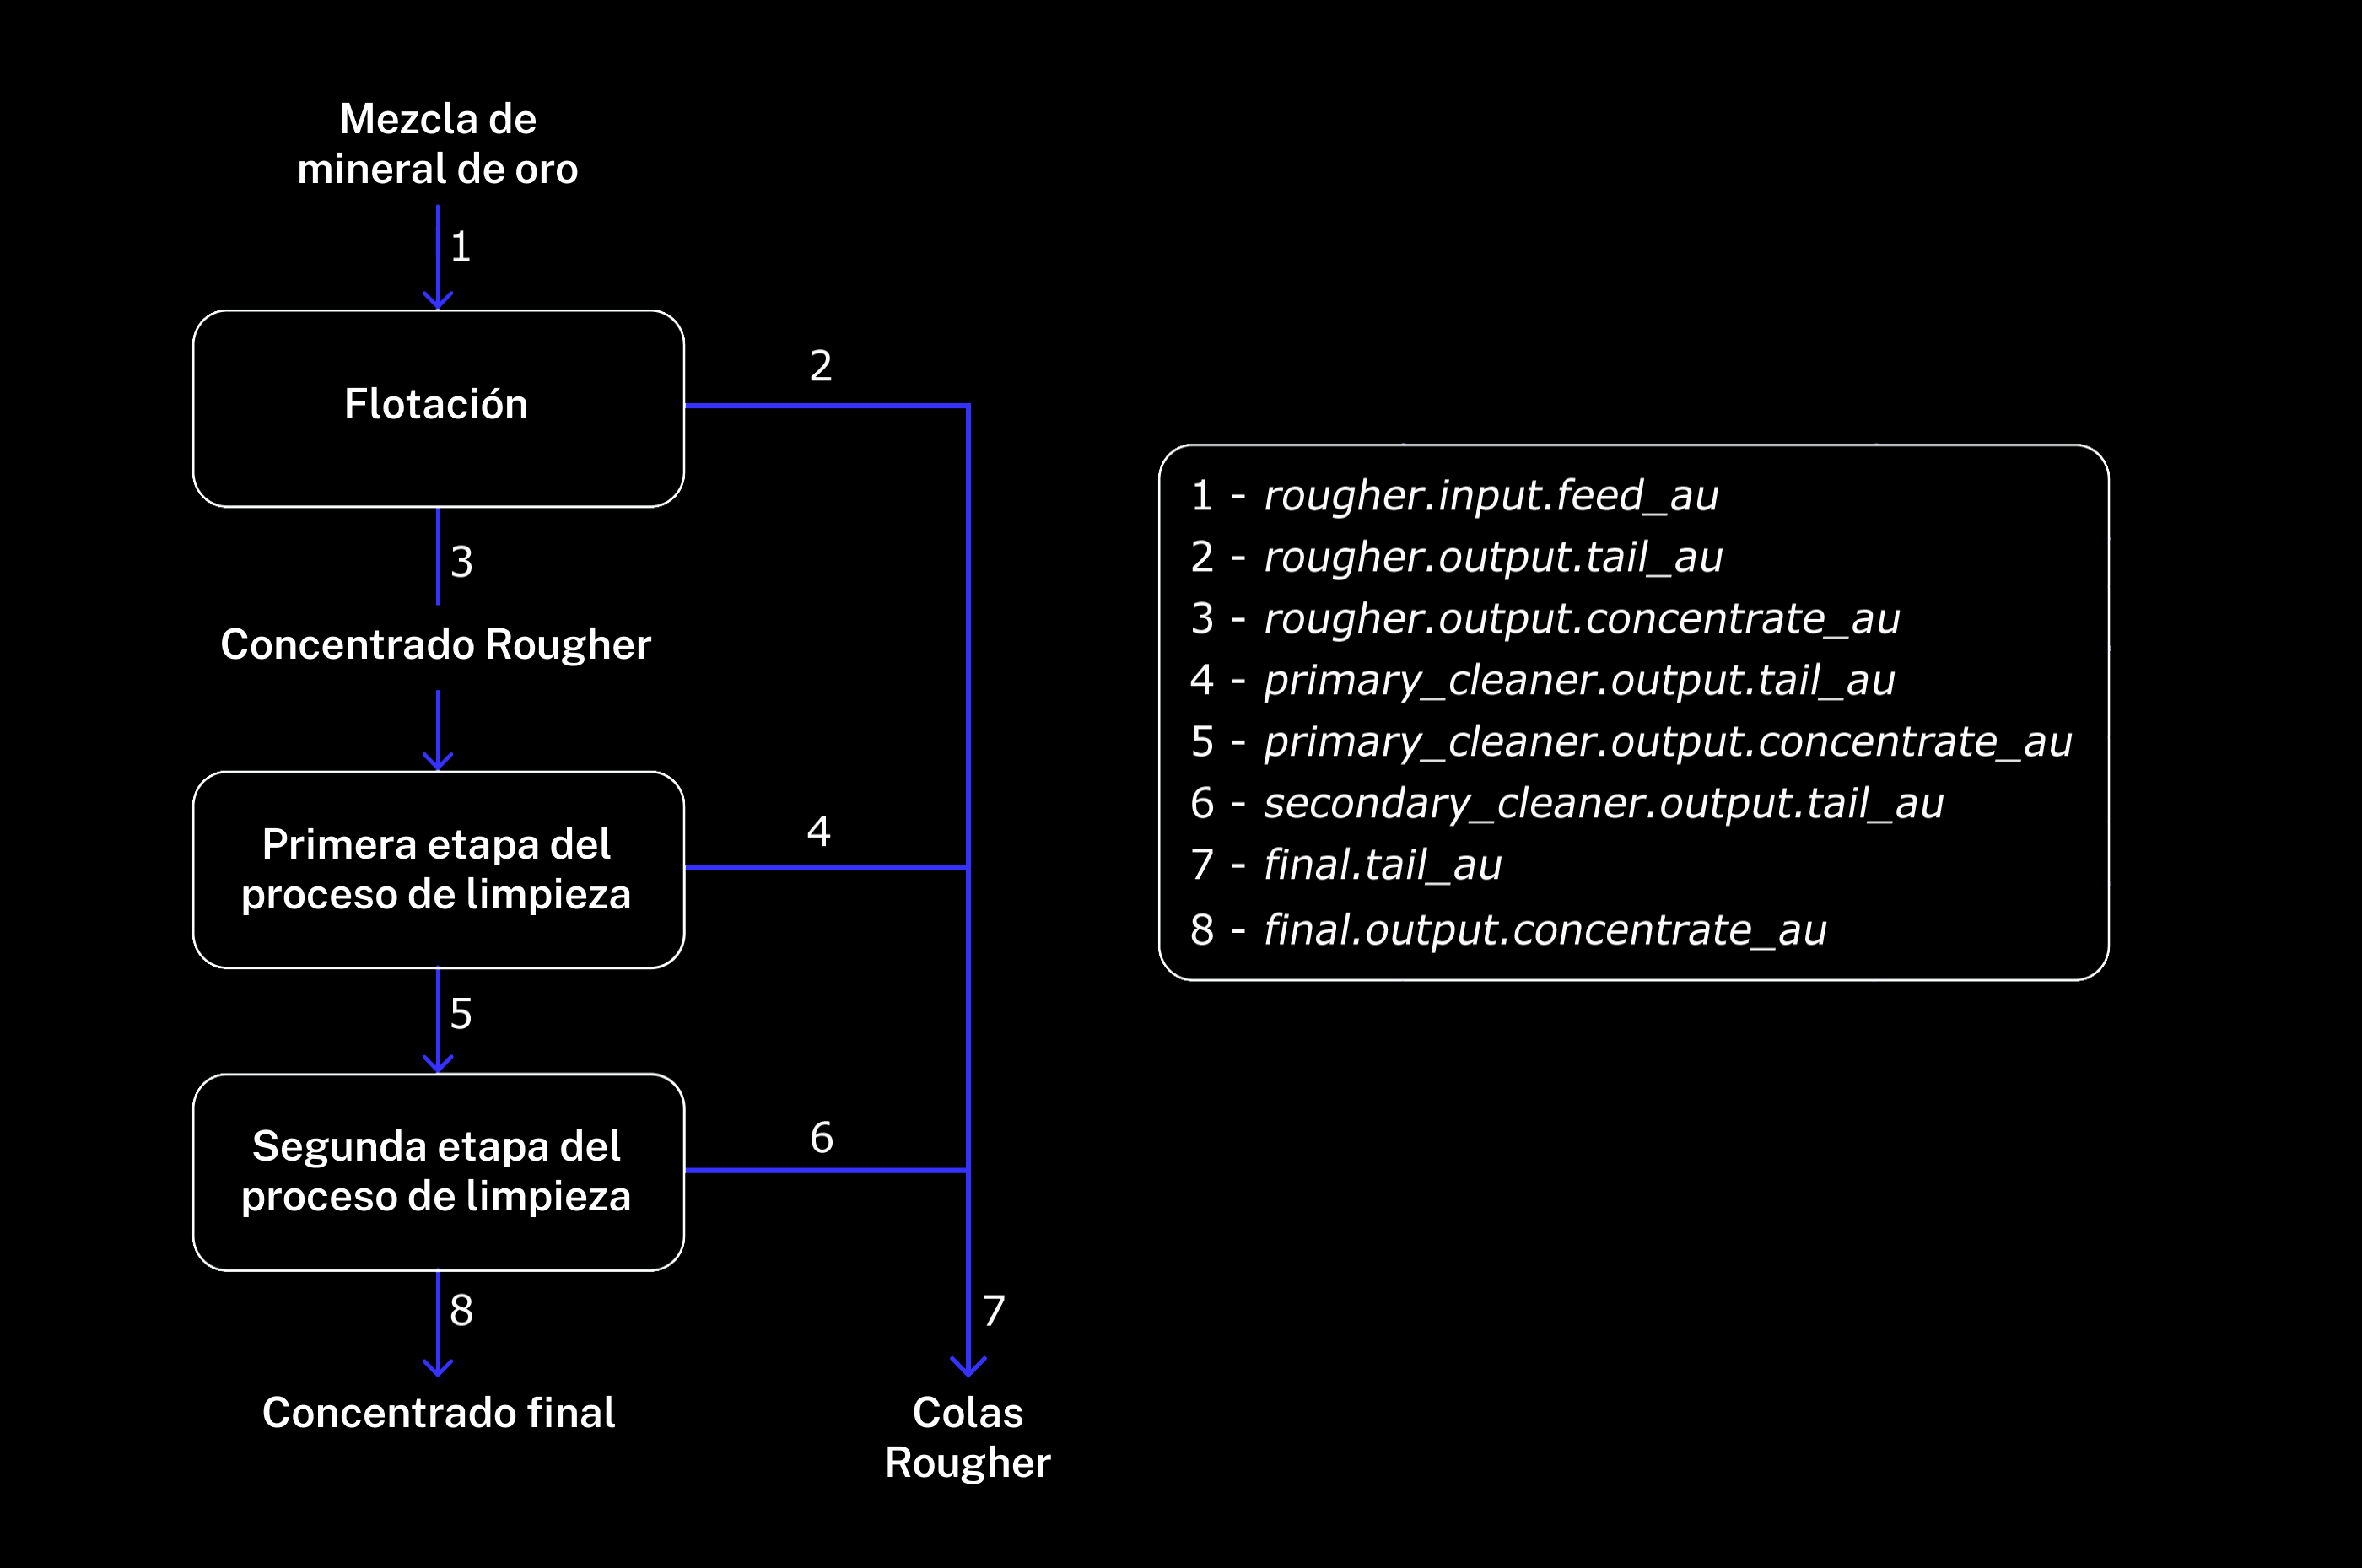

##### rougher.output.recovery

In [9]:
# Ahora filtro y elimino datos que puedan dar problemas en el cálculo del recovery
df_rougher = df_rougher[["rougher.output.concentrate_au", "rougher.input.feed_au", "rougher.output.tail_au", "rougher.output.recovery"]].copy()
df_rougher = df_rougher.rename(columns={"rougher.output.concentrate_au": "C", "rougher.input.feed_au": "F", "rougher.output.tail_au": "T", "rougher.output.recovery": "recovery_real"})

# Eliminar los valores donde C, F o T sean iguales a 0 para evitar divisiones por cero
df_rougher = df_rougher.drop(df_rougher[df_rougher["C"]==0].index)
df_rougher = df_rougher.drop(df_rougher[df_rougher["F"]==0].index)
df_rougher = df_rougher.drop(df_rougher[df_rougher["T"]==0].index)

# Eliminar filas con valores NaN
df_rougher = df_rougher.dropna()  

# Calcular la recuperación
df_rougher["recovery_estimation"] = (df_rougher["C"] * (df_rougher["F"] - df_rougher["T"])) / (df_rougher["F"] * (df_rougher["C"] - df_rougher["T"]))*100
df_rougher.info()

<class 'pandas.DataFrame'>
Index: 13967 entries, 0 to 16859
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   C                    13967 non-null  float64
 1   F                    13967 non-null  float64
 2   T                    13967 non-null  float64
 3   recovery_real        13967 non-null  float64
 4   recovery_estimation  13967 non-null  float64
dtypes: float64(5)
memory usage: 654.7 KB


In [10]:
# Ahora se calcula el MAE entre recovery_estimation y recovery_real para ver el error que se comete al usar la formula de recuperacion
mae = mean_absolute_error(df_rougher["recovery_real"], df_rougher["recovery_estimation"])
print(f"El error medio absoluto (MAE) es: {mae:.4f}")
 


El error medio absoluto (MAE) es: 0.0000


##### Conclusiones de 1.2. 
- Se observó que el recovery calculado vs el recovery de los datos, coincidecen correctamente ya que el error calculado es de  0.0000


#### 1.3. Analiza las características no disponibles en el conjunto de prueba. ¿Cuáles son estos parámetros? ¿Cuál es su tipo?

In [11]:
training_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  str    
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64
 9   final.

In [12]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   str    
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_cleaner.state.f

In [13]:
columnas_faltantes = []
for column in training_data.columns:
    if column not in test_data.columns:
        columnas_faltantes.append(column)
print("Columnas faltantes en el conjunto de prueba:", columnas_faltantes)

df_temporal = training_data[columnas_faltantes]
df_temporal.info()

Columnas faltantes en el conjunto de prueba: ['final.output.concentrate_ag', 'final.output.concentrate_pb', 'final.output.concentrate_sol', 'final.output.concentrate_au', 'final.output.recovery', 'final.output.tail_ag', 'final.output.tail_pb', 'final.output.tail_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.tail_pb', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_au', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'rougher.calculation.au_pb_ratio', 'rougher.output.concentrate_ag', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_sol', 'rougher.output.concentrate_au', 'rougher.output.recovery', 'rougher.output.tail_ag', 'rougher.output.tail_pb', '

Se aprecian cantidades de columnas diferentes entre el set de entrenamiento y el set de prueba. 

En los datos de prueba (test_data) faltan 34 columnas y dichas columnas son del tipo float.

Después de analizar los datos se entendió que el objetivo de este proyecto es entrenar el modelo usando las características que se indican test

#### 1.4. Realizar preprocesamiento de los datos


In [14]:
# Eliminar todos los valores NaN del conjunto de entrenamiento para evitar problemas en el entrenamiento de los modelos
training_data = training_data.dropna()

In [15]:
training_data.info()

<class 'pandas.DataFrame'>
Index: 11017 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                11017 non-null  str    
 1   final.output.concentrate_ag                         11017 non-null  float64
 2   final.output.concentrate_pb                         11017 non-null  float64
 3   final.output.concentrate_sol                        11017 non-null  float64
 4   final.output.concentrate_au                         11017 non-null  float64
 5   final.output.recovery                               11017 non-null  float64
 6   final.output.tail_ag                                11017 non-null  float64
 7   final.output.tail_pb                                11017 non-null  float64
 8   final.output.tail_sol                               11017 non-null  float64
 9   final.outpu

#### 2. Analisis de datos

#### 2.1. Observa cómo cambia la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación. 

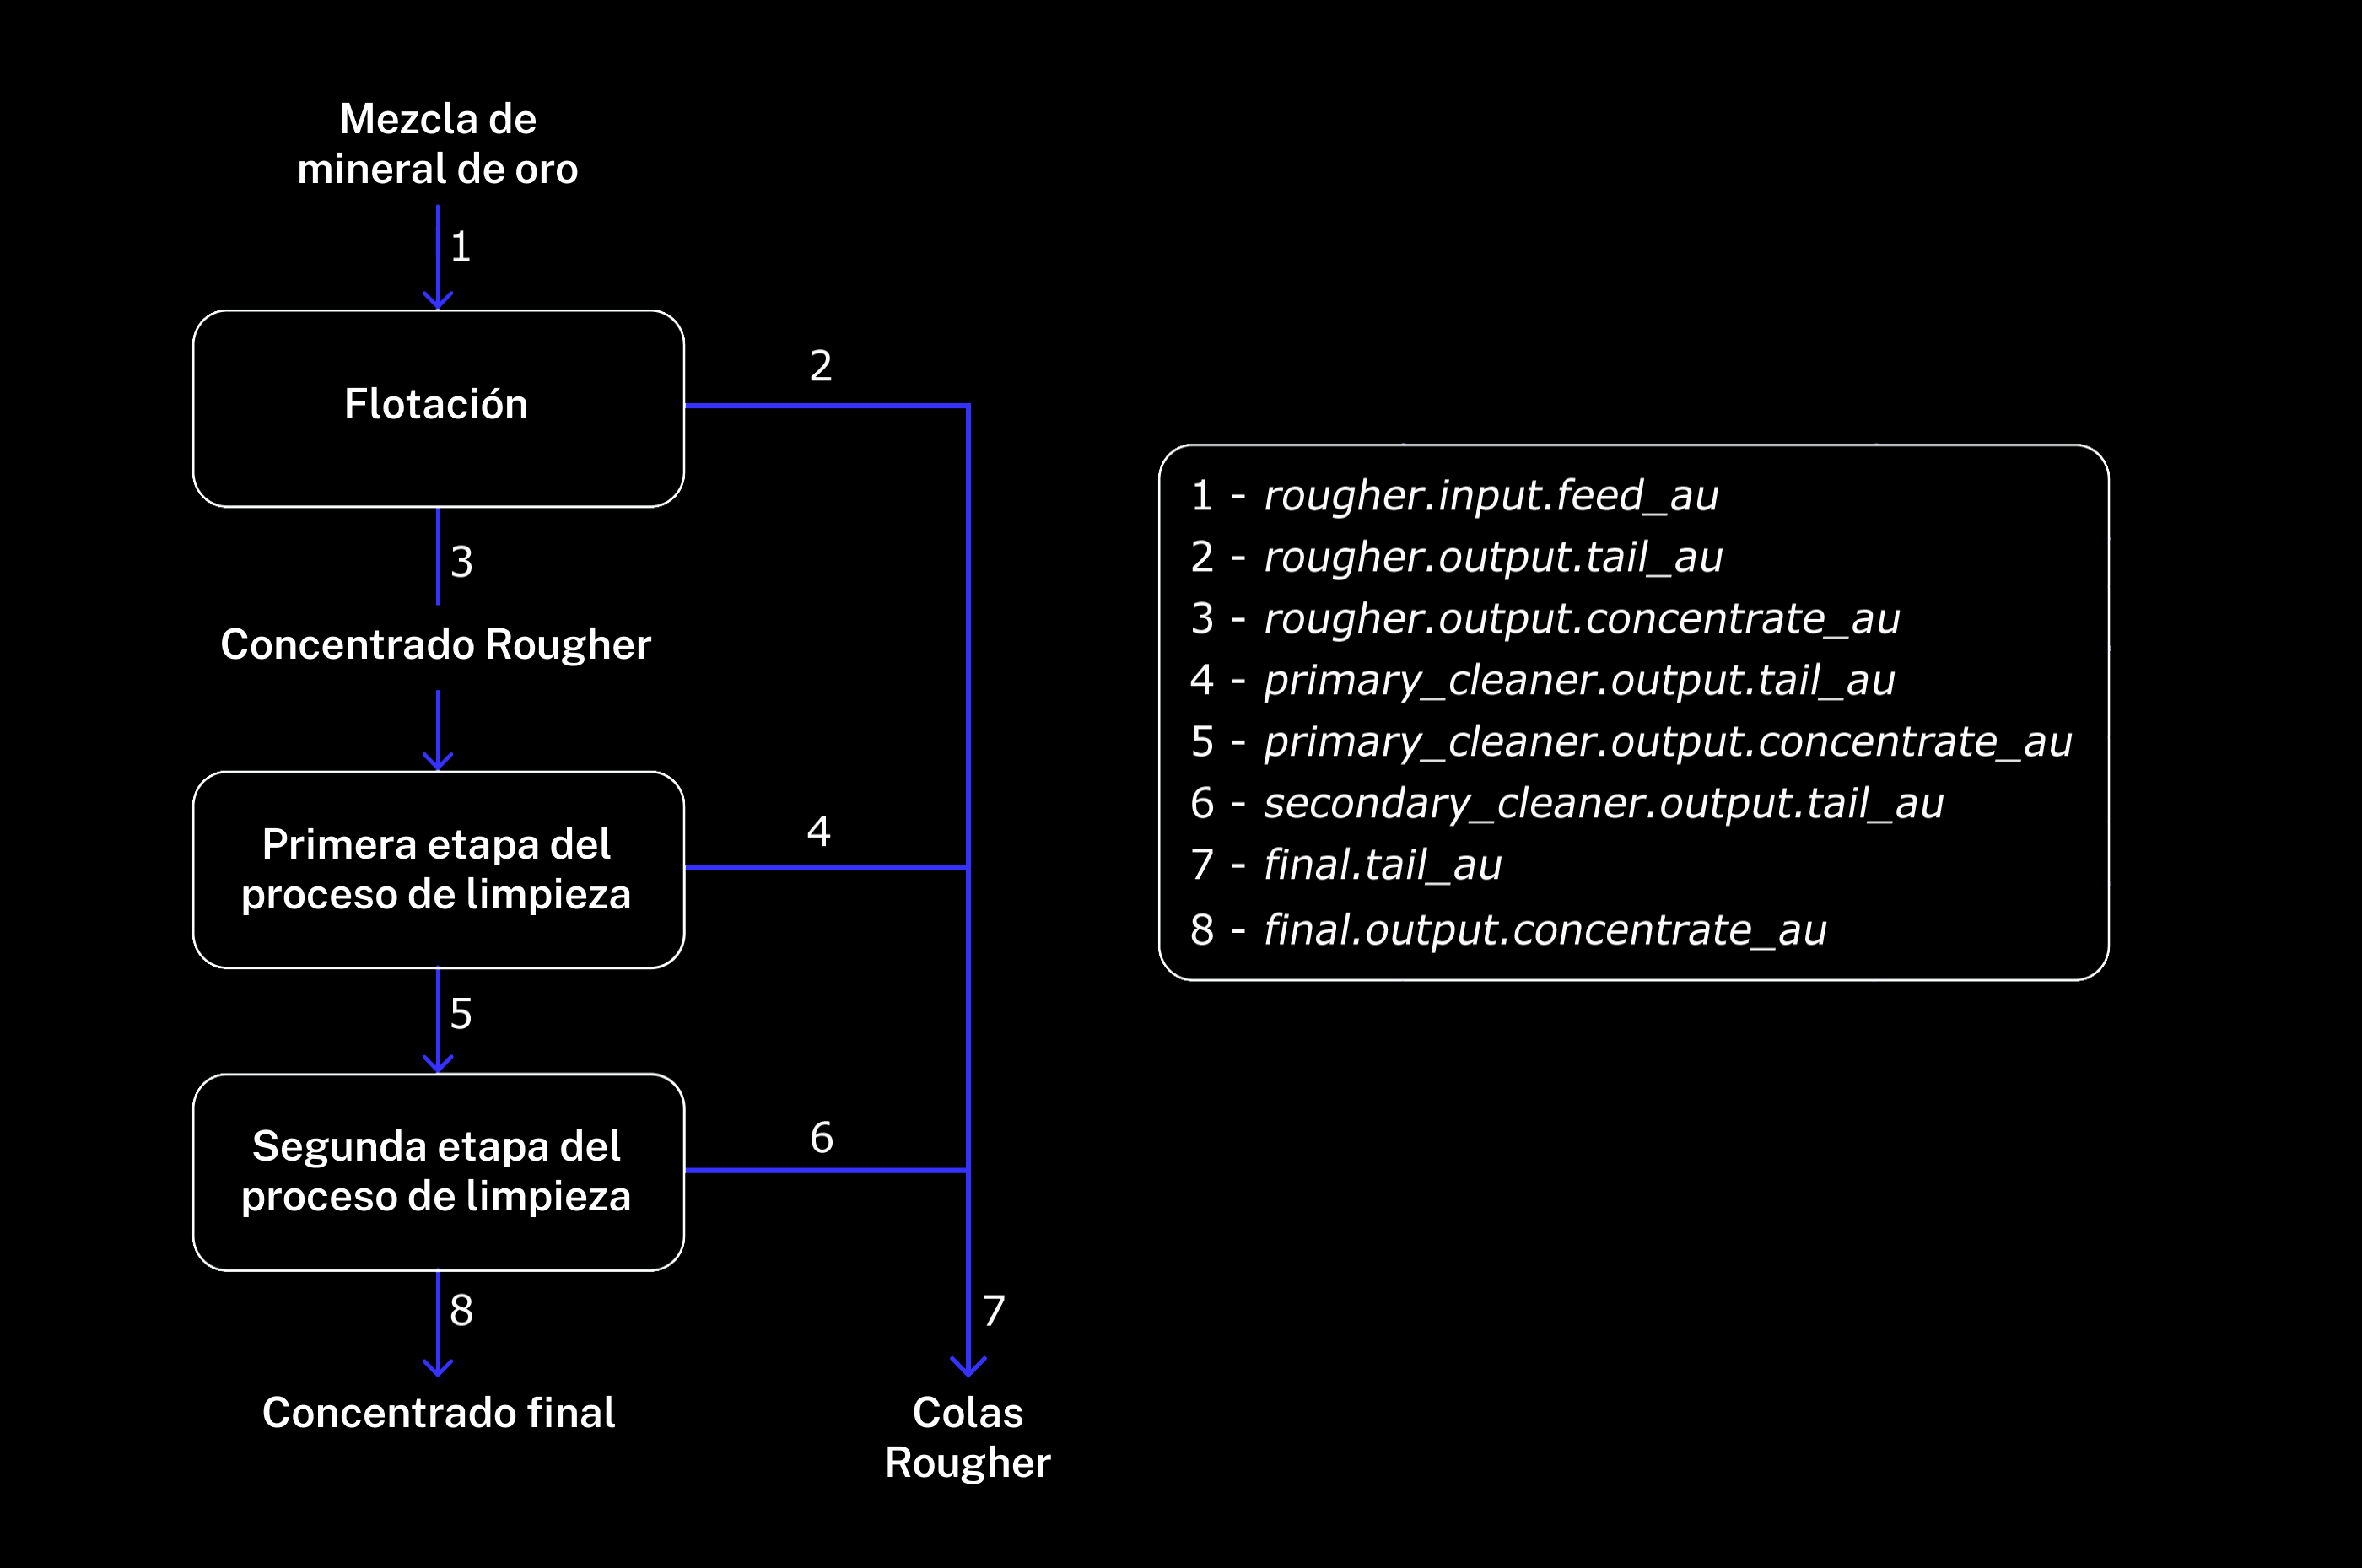

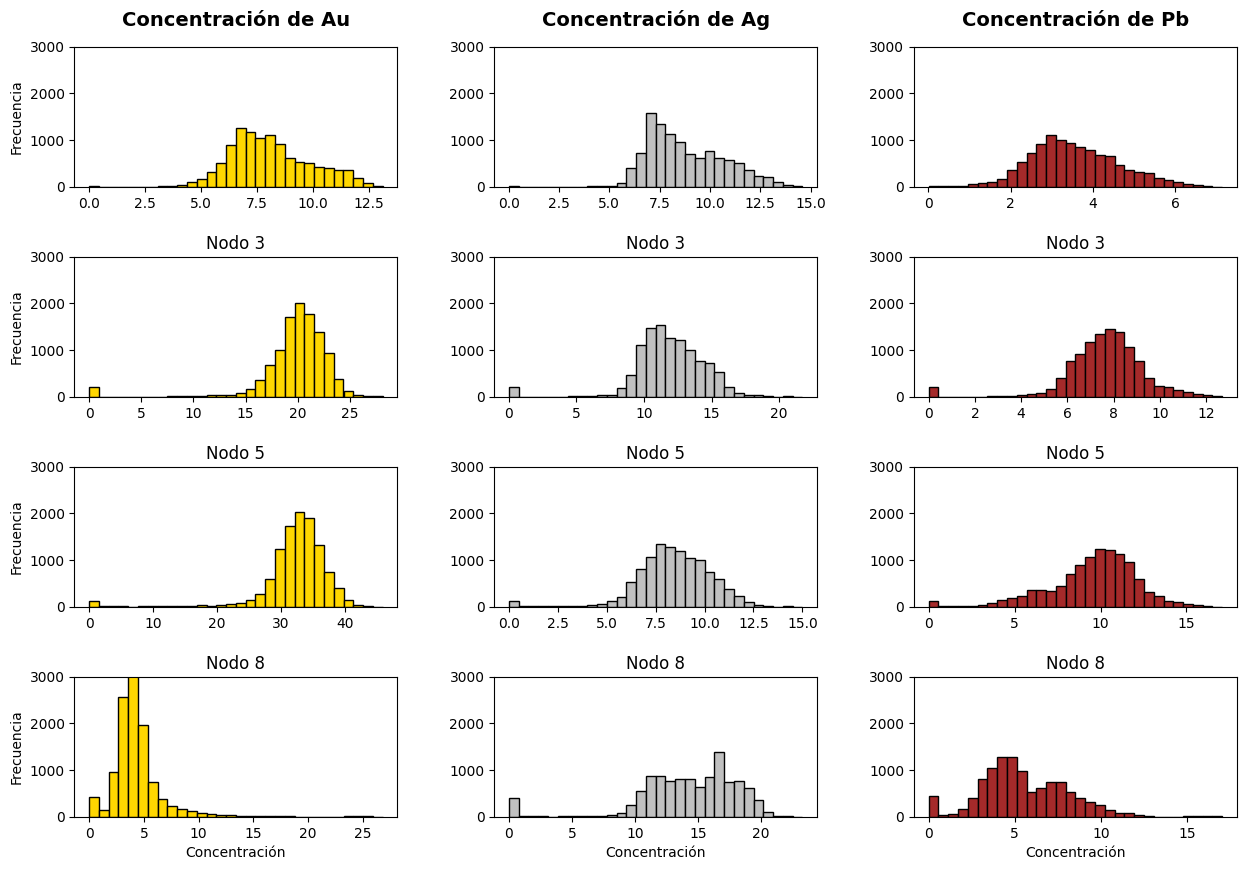

In [16]:
# 2.1.1. Figuras de concentración de Au, Ag y Pb en las diferentes etapas del proceso
figure, axes = plt.subplots(4, 3, figsize=(15, 10))

# Au
axes[0,0].hist(training_data["rougher.input.feed_au"], bins=30, color='gold', edgecolor='black')
axes[0,0].set_title("Nodo 1")
axes[1,0].hist(training_data["rougher.output.concentrate_au"], bins=30, color='gold', edgecolor='black')
axes[1,0].set_title("Nodo 3")
axes[2,0].hist(training_data["primary_cleaner.output.concentrate_au"], bins=30, color='gold', edgecolor='black')
axes[2,0].set_title("Nodo 5")
axes[3,0].hist(training_data["secondary_cleaner.output.tail_au"], bins=30, color='gold', edgecolor='black')
axes[3,0].set_title("Nodo 8")

axes[0,1].hist(training_data["rougher.input.feed_ag"], bins=30, color='silver', edgecolor='black')
axes[1,1].hist(training_data["rougher.output.concentrate_ag"], bins=30, color='silver', edgecolor='black')
axes[1,1].set_title("Nodo 3")
axes[2,1].hist(training_data["primary_cleaner.output.concentrate_ag"], bins=30, color='silver', edgecolor='black')
axes[2,1].set_title("Nodo 5")
axes[3,1].hist(training_data["secondary_cleaner.output.tail_ag"], bins=30, color='silver', edgecolor='black')
axes[3,1].set_title("Nodo 8")

axes[0,2].hist(training_data["rougher.input.feed_pb"], bins=30, color='brown', edgecolor='black')
axes[0,0].set_title("Nodo 1")
axes[1,2].hist(training_data["rougher.output.concentrate_pb"], bins=30, color='brown', edgecolor='black')
axes[1,2].set_title("Nodo 3")
axes[2,2].hist(training_data["primary_cleaner.output.concentrate_pb"], bins=30, color='brown', edgecolor='black')
axes[2,2].set_title("Nodo 5")
axes[3,2].hist(training_data["secondary_cleaner.output.tail_pb"], bins=30, color='brown', edgecolor='black')
axes[3,2].set_title("Nodo 8")

for ax in axes.flatten():
    ax.set_ylim(0, 3000)

axes[0,0].set_ylabel("Frecuencia")
axes[1,0].set_ylabel("Frecuencia")
axes[2,0].set_ylabel("Frecuencia")
axes[3,0].set_ylabel("Frecuencia")

axes[3,0].set_xlabel("Concentración")
axes[3,1].set_xlabel("Concentración")
axes[3,2].set_xlabel("Concentración")

figure.subplots_adjust(hspace=0.5 , wspace=0.3)

titulos_columnas = ['Concentración de Au', 'Concentración de Ag', 'Concentración de Pb']

# Iterar sobre los ejes de la primera fila (fila 0) y asignar el título
for ax, titulo in zip(axes[0], titulos_columnas):
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)


plt.show()


#### 2.2 Distribución del tamaño de partículas

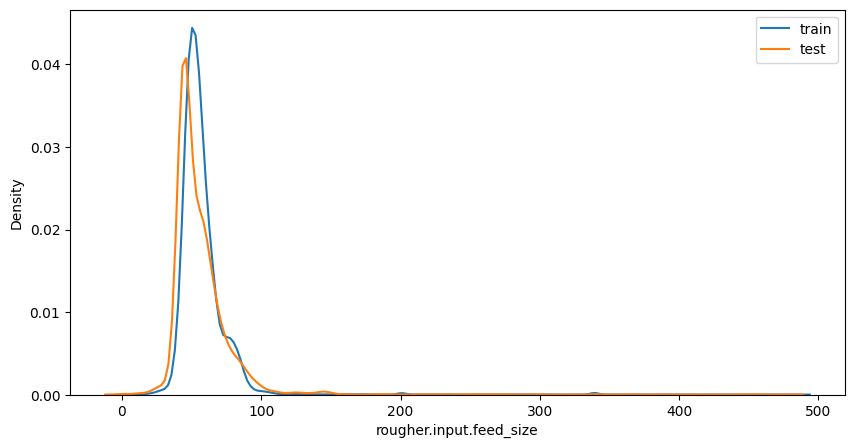

In [17]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    training_data['rougher.input.feed_size'],
    label='train'
)

sns.kdeplot(
    test_data['rougher.input.feed_size'],
    label='test'
)

plt.legend()
plt.show()

#### 2.3. Considera las concentraciones totales de todas las sustancias en las diferentes etapas: materia prima, concentrado rougher y concentrado final. ¿Observas algún valor anormal en la distribución total? Si es así, ¿merece la pena eliminar esos valores de ambas muestras? Describe los resultados y elimina las anomalías.



In [18]:
training_data["feed_total"] = (
    training_data["rougher.input.feed_au"]
    + training_data["rougher.input.feed_ag"]
    + training_data["rougher.input.feed_pb"]
    + training_data["rougher.input.feed_sol"]
)

training_data["rougher_total"] = (
    training_data["rougher.output.concentrate_au"]
    + training_data["rougher.output.concentrate_ag"]
    + training_data["rougher.output.concentrate_pb"]
    + training_data["rougher.output.concentrate_sol"]
)

training_data["final_total"] = (
    training_data["final.output.concentrate_au"]
    + training_data["final.output.concentrate_ag"]
    + training_data["final.output.concentrate_pb"]
    + training_data["final.output.concentrate_sol"]
)

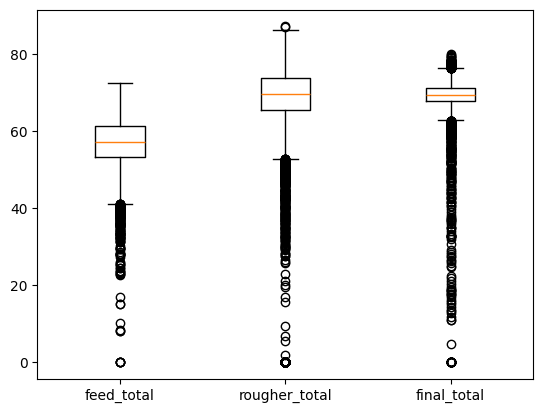

In [19]:
figure = plt.figure()
plt.boxplot(x=[training_data["feed_total"], training_data["rougher_total"], training_data["final_total"]], tick_labels=["feed_total", "rougher_total", "final_total"])
plt.show();

Nota: Es raro que existan valores de entrada cuyo total sea 0, ya que eso implicaría que no hay nada en la alimentación. Esto podría indicar un error en la recolección de datos o en el proceso de alimentación. Se decidió eliminar las filas donde esto ocurre

In [20]:
training_data = training_data[(training_data["feed_total"] > 0) & (training_data["rougher_total"] > 0) & (training_data["final_total"] > 0)]

In [21]:
training_data.info()

<class 'pandas.DataFrame'>
Index: 10784 entries, 0 to 16859
Data columns (total 90 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                10784 non-null  str    
 1   final.output.concentrate_ag                         10784 non-null  float64
 2   final.output.concentrate_pb                         10784 non-null  float64
 3   final.output.concentrate_sol                        10784 non-null  float64
 4   final.output.concentrate_au                         10784 non-null  float64
 5   final.output.recovery                               10784 non-null  float64
 6   final.output.tail_ag                                10784 non-null  float64
 7   final.output.tail_pb                                10784 non-null  float64
 8   final.output.tail_sol                               10784 non-null  float64
 9   final.outpu

#### 3. Construcción del modelo
#### 3.1. Construir la función para calcular sMAPE


In [22]:
def smape(y_true, y_pred):
    n = len(y_true)
    smape_value = (1/n) * sum(2* abs(y_true - y_pred) / (abs(y_true) + abs(y_pred))) *100
    return smape_value

# Hacer una función de scoring personalizada para usar SMAPE en cross_validate
smape_scorer = make_scorer(
    smape,
    greater_is_better=False
)

#### 3.2. Entrena diferentes modelos. Evalúalos aplicando la validación cruzada. Elige el mejor modelo y pruébalo utilizando la muestra de prueba. Facilita los resultados.

In [23]:
# Para entrenar los modelos se deben utilizar las columnas que se indican en el dataset de prueba como los features; y hay dos targets: 
# rougher.output.recovery y final.output.recovery. 
# Se debe entrenar un modelo para cada target.

columnas_de_interes = list(test_data.columns)

# Datos para la primera recuperación (rougher)
features = training_data[columnas_de_interes].drop(columns=["date"])
target_rougher = training_data["rougher.output.recovery"]
target_final = training_data["final.output.recovery"]

# Se usaran los datos escalados para el modelo lineal
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [ ]:
# Preparar diccionario para guardar los datos, resultados y los modelos
resultados = {
    
    "data": {
        "features": features,
        "features_scaled": features_scaled,
        "target_rougher": target_rougher,
        "target_final": target_final,
    },
    
    "recovery_rougher": {  
    
        "Modelo lineal": {
            "r2_score": None,
            "smape_score": None,
            "model": None,},
        
        "Random Forest": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
        }
    },
    
    "recovery_final": {  
       
        "Modelo lineal": {
            "r2_score": None,
            "smape_score": None,
            "model": None,},
        
        "Random Forest": {
            "r2_score": None,
            "smape_score": None,
            "model": None,
        }
    },
}

##### 5.2. Modelos para el primer recovery (rougher):

#### 5.2.1. Modelo lineal

In [31]:
model = LinearRegression()
scores = cross_validate(
        model,
        features_scaled, 
        target_rougher, 
        cv =5, 
        scoring = {
                "r2": "r2",
                "sMAPE": smape_scorer}
)

r2_mean = -scores["test_r2"].mean()
smape_mean = -scores["test_sMAPE"].mean()        

print(f"El r2 del modelo lineal: {r2_mean:.4f}")
print(f"El sMAPE del modelo lineal: {smape_mean:.4f}")

# # Guardar los resultados y el modelo en el diccionario
# resultados["recovery_rougher"]["Modelo lineal"]["sMAPE_score"] = model_score
# resultados["recovery_rougher"]["Modelo lineal"]["model"] = model


El r2 del modelo lineal: 0.5063
El sMAPE del modelo lineal: 6.1681


#### 5.2.2. Random Forest

In [ ]:
best_r2_score = 0
best_estimator = 0
best_depth = 0

n_estimators = [10, 50, 100, 200, 250, 300]
max_depths = [2, 4, 6, 8, 10]

for n in n_estimators:
    for d in max_depths:
        model = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=12345)
        model.fit(features, target_rougher)
        recovery_predicted = model.predict(features)
        score = model.score(features, target_rougher)
        if score > best_r2_score:
            best_r2_score = score
            best_estimator = n
            best_depth = d
            
print(f"Mejor R^2 score del modelo Random Forest: {best_r2_score} con n_estimators={best_estimator} y max_depth={best_depth}")    


In [ ]:
# Usar los mejores hiperparámetros para entrenar al modelo final de random forest y guardar los resultados en el diccionario
model = RandomForestRegressor(n_estimators=best_estimator, max_depth=best_depth, random_state=12345)
model.fit(features_rougher, target_rougher)
recovery_predicted = model.predict(features_rougher)
score = model.score(features_rougher, target_rougher)
mse = mean_squared_error(target_rougher, recovery_predicted) 

resultados["recovery_rougher"]["Random Forest"]["r2_score"] = score
resultados["recovery_rougher"]["Random Forest"]["mse"] = mse
resultados["recovery_rougher"]["Random Forest"]["recovery_predicted"] = recovery_predicted
resultados["recovery_rougher"]["Random Forest"]["model"] = model

print(f"R^2 score del modelo Random Forest: {score:.4f}")
print(f"mean_squared_error del modelo Random Forest: {mse:.4f}")

#### 5.3. Modelos del segundo recovery (final):


#### 5.3.1. Modelo lineal

In [ ]:
model = LinearRegression()
model.fit(features_final, target_final)
recovery_predicted = model.predict(features_final)
model_score = model.score(features_final, target_final)
print(f"R^2 score del modelo lineal: {model_score:.4f}")
print(f"mean_squared_error del modelo lineal: {mean_squared_error(target_final, recovery_predicted):.4f}")

# Guardar los resultados y el modelo en el diccionario
resultados["recovery_final"]["Modelo lineal"]["r2_score"] = model_score
resultados["recovery_final"]["Modelo lineal"]["mse"] = mean_squared_error(target_final, recovery_predicted)
resultados["recovery_final"]["Modelo lineal"]["recovery_predicted"] = recovery_predicted
resultados["recovery_final"]["Modelo lineal"]["model"] = model

#### 5.3.2. Random Forest

In [ ]:
best_r2_score = 0
best_estimator = 0
best_depth = 0

n_estimators = [10, 50, 100, 200, 250, 300]
max_depths = [2, 4, 6, 8, 10]

for n in n_estimators:
    for d in max_depths:
        model = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=12345)
        model.fit(features_final, target_final)
        recovery_predicted = model.predict(features_final)
        score = model.score(features_final, target_final)
        if score > best_r2_score:
            best_r2_score = score
            best_estimator = n
            best_depth = d
            
print(f"Mejor R^2 score del modelo Random Forest: {best_r2_score} con n_estimators={best_estimator} y max_depth={best_depth}") 

In [ ]:
# Usar los mejores hiperparámetros para entrenar al modelo final de random forest y guardar los resultados en el diccionario
model = RandomForestRegressor(n_estimators=best_estimator, max_depth=best_depth, random_state=12345)
model.fit(features_final, target_final)
recovery_predicted = model.predict(features_final)
score = model.score(features_final, target_final)
mse = mean_squared_error(target_final, recovery_predicted) 

resultados["recovery_final"]["Random Forest"]["r2_score"] = score
resultados["recovery_final"]["Random Forest"]["mse"] = mse
resultados["recovery_final"]["Random Forest"]["recovery_predicted"] = recovery_predicted
resultados["recovery_final"]["Random Forest"]["model"] = model

print(f"R^2 score del modelo Random Forest: {score:.4f}")
print(f"mean_squared_error del modelo Random Forest: {mse:.4f}")

#### 6. Función para calcular el sMAPE (error medio absoluto porcentual absoluto)

#### 7. Calculo del sMAPE final

In [ ]:
recovery_rougher = resultados["recovery_rougher"]["Random Forest"]["recovery_predicted"]
recovery_final = resultados["recovery_final"]["Random Forest"]["recovery_predicted"]
sMAPE_final = 0.25 * smape(target_rougher, recovery_rougher) + 0.75 * smape(target_final, recovery_final)
print(f"sMAPE final: {sMAPE_final:.4f}%")

#### 8. Conclusiones hasta este punto.
- Se entrenaron dos modelos para cada recovery del proceso.
- En ambos recoveries el modelo de Random Forest obtuvo los mejores resultados con un r^2 de 0.99 y con un error cuadrático medio inferior a 0.7 para ambos modelos, esto quiere decir que los modelos se ajustaron correctamente a los datos y tuvieron una excelente predicción de los datos.
- El sMAPE confirma los resultados obtenidos anteriormente; ya que esta métrica expresa el error entre las predicciones y el resultado real de forma porcentual, el valor obtenido de 0.6254% indica un error bajo
- Se almacenaron los resultados así como el modelo usando joblib para usarlos en las pruebas del modelo.


NOTA: Se supone que ahora se usaría otro cuaderno de jupyter para hacer las pruebas. Sin embargo, en esta oportunidad se hará a continuación.

#### 9. Usar modelos entrenados para hacer las pruebas y contrastar resultados

#### 9.1. Cargar datos de prueba

In [ ]:
df_test = load_data(folder, "gold_recovery_test.csv")
df_test.info()

#### 9.2. Crear los dataframes con los datos rougher y final para el test, aplicando el mismo procedimiento que se hizo con el training data.

In [ ]:
df_rougher_test = df_test[["rougher.output.concentrate_au", "rougher.input.feed_au", "rougher.output.tail_au"]].copy()
df_rougher_test = df_rougher_test.rename(columns={"rougher.output.concentrate_au": "C", "rougher.input.feed_au": "F", "rougher.output.tail_au": "T"})

df_final_test = df_test[["final.output.concentrate_au","rougher.input.feed_au","final.output.tail_au"]].copy()
df_final_test = df_final_test.rename(columns={"final.output.concentrate_au": "C", "rougher.input.feed_au": "F", "final.output.tail_au": "T"})